Carga de librerías

In [1]:
import pandas as pd
import os
import json
from dotenv import load_dotenv
import requests
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from datetime import timedelta
import holidays
import itertools

In [2]:
import sys
from pathlib import Path

for candidato in (Path.cwd(), *Path.cwd().resolve().parents):
    if (candidato / "src").is_dir():
        if str(candidato) not in sys.path:
            sys.path.insert(0, str(candidato))
        break

from src.paths import RAIZ, DIR_PROCESSED, DIR_REPORTS

Carga de datos

El objetivo modelado es `demanda_real` (indicador 1293).

In [3]:
RUTA_FICHERO = DIR_PROCESSED / "demanda_horaria.parquet"
df_verif = pd.read_parquet(RUTA_FICHERO)

assert df_verif.shape == (30648, 4), f"Shape inesperado: {df_verif.shape}"
print(df_verif.head())

               datetime_utc  demanda_real  demanda_prevista  es_evento
0 2023-01-01 00:00:00+00:00  19292.000000      19383.750000      False
1 2023-01-01 01:00:00+00:00  18155.416667      18216.083333      False
2 2023-01-01 02:00:00+00:00  17120.083333      17126.666667      False
3 2023-01-01 03:00:00+00:00  16552.583333      16551.666667      False
4 2023-01-01 04:00:00+00:00  16191.000000      16185.750000      False


## Feature calendario

In [4]:
# 1. Crear la copia explícita del DataFrame horario
df_features = df_verif.copy()

# 2. Convertir temporalmente a la zona horaria de Madrid para extraer las características locales
# .dt.tz_convert mantiene el trasfondo UTC pero permite extraer los componentes en hora local
datetime_madrid = df_features["datetime_utc"].dt.tz_convert("Europe/Madrid")

# 3. Derivar las columnas solicitadas basadas en el calendario local
df_features["hora"] = datetime_madrid.dt.hour
df_features["mes"] = datetime_madrid.dt.month

# tipo_dia: laborable (0-4 son L-V) o finde (5-6 son S-D)
df_features["tipo_dia"] = np.where(
    datetime_madrid.dt.weekday < 5, "laborable", "finde"
)

# 4. Verificaciones obligatorias: conteo e inspección visual
print(f"Conteo total de registros: {len(df_features)}")
assert (
    len(df_features) == 30648
), f"¡Alerta! El conteo ha variado: {len(df_features)}"

print("\n--- HEAD DEL DATAFRAME PROCESADO ---")
print(
    df_features.head()
)

Conteo total de registros: 30648

--- HEAD DEL DATAFRAME PROCESADO ---
               datetime_utc  demanda_real  demanda_prevista  es_evento  hora  \
0 2023-01-01 00:00:00+00:00  19292.000000      19383.750000      False     1   
1 2023-01-01 01:00:00+00:00  18155.416667      18216.083333      False     2   
2 2023-01-01 02:00:00+00:00  17120.083333      17126.666667      False     3   
3 2023-01-01 03:00:00+00:00  16552.583333      16551.666667      False     4   
4 2023-01-01 04:00:00+00:00  16191.000000      16185.750000      False     5   

   mes tipo_dia  
0    1    finde  
1    1    finde  
2    1    finde  
3    1    finde  
4    1    finde  


Festivos + puentes

`holidays.ES(observed=False)` con `observed=True` (el default de la librería) los festivos que caen en domingo desaparecen del calendario -- Año Nuevo 2023 se perdía. `observed=False` da el calendario civil real. Solo festivos nacionales (los autonómicos sobre-marcarían para demanda peninsular agregada).

In [5]:
# 1. Obtener los días únicos en fecha local para calcular los festivos eficientemente
# (Trabajar a nivel de día y luego mapear al dataframe de horas ahorra muchísima memoria)
fechas_locales = datetime_madrid.dt.date.unique()
años_presentes = datetime_madrid.dt.year.unique()

# 2. Inicializar el calendario de festivos nacionales de España
es_holidays = holidays.ES(years=años_presentes, observed=False)

# 3. Determinar qué días son festivos y cuáles son puentes a nivel diario
festivos_set = {d for d in fechas_locales if d in es_holidays}
findes_set = {
    d for d in fechas_locales if d.weekday() >= 5
}  # 5=Sábado, 6=Domingo

puentes_set = set()
for d in fechas_locales:
    # Un puente debe ser un día laborable y no festivo
    if d not in festivos_set and d not in findes_set:
        mañana = d + timedelta(days=1)
        ayer = d - timedelta(days=1)

        # Caso A: Lunes puente (Martes festivo y Domingo fin de semana)
        # Caso B: Viernes puente (Jueves festivo y Sábado fin de semana)
        if (mañana in festivos_set and ayer in findes_set) or (
            ayer in festivos_set and mañana in findes_set
        ):
            puentes_set.add(d)

# 4. Mapear los resultados diarios de vuelta al DataFrame horario (usando la fecha local)
df_features["fecha_local"] = datetime_madrid.dt.date

df_features["es_festivo"] = df_features["fecha_local"].isin(festivos_set)
df_features["es_puente"] = df_features["fecha_local"].isin(puentes_set)

# Eliminamos la columna auxiliar de fecha para dejar el endpoint limpio
df_features.drop(columns=["fecha_local"], inplace=True)

# 5. VERIFICACIONES OBLIGATORIAS

# A. Conteo intacto
print(f"Conteo total de registros: {len(df_features)}")
assert (
    len(df_features) == 30648
), f"¡Alerta! El conteo ha variado: {len(df_features)}"

# B. Comprobación del caso conocido: 2023-01-01 (Año Nuevo en Domingo)
# Buscamos la fila de las 00:00:00 UTC, que corresponde a la 01:00:00 de Madrid
caso_test = df_features[
    df_features["datetime_utc"] == "2023-01-01 00:00:00+00:00"
]

print("\n--- COMPROBACIÓN TEST (2023-01-01) ---")
print(caso_test[["datetime_utc", "tipo_dia", "es_festivo", "es_puente"]])

Conteo total de registros: 30648

--- COMPROBACIÓN TEST (2023-01-01) ---
               datetime_utc tipo_dia  es_festivo  es_puente
0 2023-01-01 00:00:00+00:00    finde        True      False


In [6]:
df_features["tipo_efectivo"] = np.where(
    (df_features["tipo_dia"] == "finde") | (df_features["es_festivo"] == True),
    "no_laborable",
    "laborable",
)
df_features.head()

,datetime_utc,demanda_real,demanda_prevista,es_evento,hora,mes,tipo_dia,es_festivo,es_puente,tipo_efectivo
0,2023-01-01 00:00:00+00:00,19292.000000,19383.750000,False,1,1,finde,True,False,no_laborable
1,2023-01-01 01:00:00+00:00,18155.416667,18216.083333,False,2,1,finde,True,False,no_laborable
2,2023-01-01 02:00:00+00:00,17120.083333,17126.666667,False,3,1,finde,True,False,no_laborable
3,2023-01-01 03:00:00+00:00,16552.583333,16551.666667,False,4,1,finde,True,False,no_laborable
4,2023-01-01 04:00:00+00:00,16191.000000,16185.750000,False,5,1,finde,True,False,no_laborable


In [7]:
# Definimos el mapeo binario para 'tipo_efectivo'
mapeo_tipo_efectivo = {
    "laborable": 0, 
    "no_laborable": 1
}

print("--- MAPEO CATEGÓRICO ---")
print(f"Aplicando mapeo explícito a 'tipo_efectivo': {mapeo_tipo_efectivo}")

# Aplicamos el mapeo sobre la serie completa original
df_features["tipo_efectivo"] = df_features["tipo_efectivo"].map(mapeo_tipo_efectivo)

# Verificación de seguridad para asegurar que todo ha coincidido perfectamente
nulos_post_mapeo = df_features["tipo_efectivo"].isna().sum()
assert nulos_post_mapeo == 0, f"¡Alerta! Hay {nulos_post_mapeo} valores en 'tipo_efectivo' que no se mapearon. Revisa si el texto es exactamente 'laborable' o 'no_laborable'."
print("✔ Mapeo binario completado con éxito.")

--- MAPEO CATEGÓRICO ---
Aplicando mapeo explícito a 'tipo_efectivo': {'laborable': 0, 'no_laborable': 1}
✔ Mapeo binario completado con éxito.


## Partición temporal: train 2023–2025, test 2026 H1

Partición estrictamente temporal: es una serie temporal, y mezclarla
filtraría información del futuro hacia el pasado. El corte cae en la frontera de año.

Dato importante: En 2026 la demanda media (test) está unos 2.237 MW por encima de la de
train, un nivel que el modelo no ha visto nunca. Eso explica el
sesgo sistemático de las secciones siguientes y limita lo que la validación de 2025
puede llegar a medir.

In [8]:
# 1. Extraer el año directamente de la clave UTC para hacer la partición
años_utc = df_features["datetime_utc"].dt.year

# 2. Crear las particiones temporales (sin barajar)
train = df_features[años_utc.isin([2023, 2024, 2025])].copy()
test = df_features[años_utc == 2026].copy()

# 3. VERIFICACIONES OBLIGATORIAS DE LOS CORTES

print("--- VALIDACIÓN DE FECHAS LÍMITE ---")
print(f"Train: desde {train['datetime_utc'].min()} hasta {train['datetime_utc'].max()}")
print(f"Test:  desde {test['datetime_utc'].min()} hasta {test['datetime_utc'].max()}")

print("\n--- VALIDACIÓN DE REGISTROS Y VOLUMEN ---")
filas_train = len(train)
filas_test = len(test)
total_particiones = filas_train + filas_test
total_original = len(df_features)

print(f"Filas en Train: {filas_train}")
print(f"Filas en Test:  {filas_test}")
print(f"Suma de particiones: {total_particiones} | Total esperado: {total_original}")

# Assertions de seguridad
assert total_particiones == total_original, f"¡Alerta! Las filas no cuadran. Suma: {total_particiones}"
assert train["datetime_utc"].max() < test["datetime_utc"].min(), "¡Alerta! Existe solapamiento temporal entre Train y Test."

print("\n✔ Partición temporal completada con éxito. Cero solapamientos.")

--- VALIDACIÓN DE FECHAS LÍMITE ---
Train: desde 2023-01-01 00:00:00+00:00 hasta 2025-12-31 23:00:00+00:00
Test:  desde 2026-01-01 00:00:00+00:00 hasta 2026-06-30 23:00:00+00:00

--- VALIDACIÓN DE REGISTROS Y VOLUMEN ---
Filas en Train: 26304
Filas en Test:  4344
Suma de particiones: 30648 | Total esperado: 30648

✔ Partición temporal completada con éxito. Cero solapamientos.


Tabla de medias

Esta tabla de medias por `(tipo_efectivo, mes, hora)` es la referencia de calendario

In [9]:
# 1. Filtrar train excluyendo los eventos (~es_evento)
# Solo nos interesa la columna de demanda_real para las agrupaciones
train_limpio = train[~train["es_evento"]].copy()

# 2. Calcular la tabla de medias y el conteo (n) por cada combinación
tabla_medias = (
    train_limpio.groupby(["tipo_efectivo", "mes", "hora"])["demanda_real"]
    .agg(media="mean", n="count")
    .reset_index()
)

# ==========================================
#         VERIFICACIONES DE ENDPOINT
# ==========================================

# VERIFICACIÓN 1: Conteo de filas utilizadas en el filtrado
filas_esperadas = 26304 - 37  # 26.267
filas_reales = len(train_limpio)
print(f"Filas en train antes del filtro: {len(train)}")
print(f"Filas utilizadas para las medias: {filas_reales}")
assert (
    filas_reales == filas_esperadas
), f"¡Alerta! El filtro es_evento no ha restado exactamente 37 horas. Filas actuales: {filas_reales}"

# VERIFICACIÓN 2: Dimensión exacta de la tabla (576 celdas)
# 2 (laborable/no_laborable) * 12 (meses) * 24 (horas) = 576
total_combinaciones = len(tabla_medias)
print(f"Total de combinaciones (grupos) generados: {total_combinaciones}")
assert (
    total_combinaciones == 576
), f"¡Alerta! Faltan combinaciones en el histórico. Grupos actuales: {total_combinaciones}"

# VERIFICACIÓN 3: Ausencia de valores nulos (NaN) en las medias
valores_nulos = tabla_medias["media"].isna().sum()
print(f"Valores NaN encontrados en la columna 'media': {valores_nulos}")
assert (
    valores_nulos == 0
), "¡Alerta! Se han detectado valores NaN en la tabla de medias."

# VERIFICACIÓN 4: Inspección de volúmenes (n)
# Buscamos extremos para asegurar que ninguna combinación tenga un n peligrosamente bajo
min_n = tabla_medias["n"].min()
max_n = tabla_medias["n"].max()
print(f"Muestra de volumen de muestras por grupo (n) -> Mínimo: {min_n} | Máximo: {max_n}")
assert (
    min_n >= 10
), f"¡Alerta! Hay combinaciones con n de un solo dígito. Mínimo actual: {min_n}"

# 3. Ojear la estructura del Endpoint
print("\n--- VISTA PREVIA DE LA TABLA DE MEDIAS ---")
print(tabla_medias.head(10))

Filas en train antes del filtro: 26304
Filas utilizadas para las medias: 26267
Total de combinaciones (grupos) generados: 576
Valores NaN encontrados en la columna 'media': 0
Muestra de volumen de muestras por grupo (n) -> Mínimo: 24 | Máximo: 67

--- VISTA PREVIA DE LA TABLA DE MEDIAS ---
   tipo_efectivo  mes  hora         media   n
0              0    1     0  25631.065104  64
1              0    1     1  23896.888021  64
2              0    1     2  22788.279948  64
3              0    1     3  22312.632812  64
4              0    1     4  22256.516927  64
5              0    1     5  22938.730469  64
6              0    1     6  25872.122396  64
7              0    1     7  30316.901042  64
8              0    1     8  32970.442708  64
9              0    1     9  33572.825521  64


MAE REE

El benchmark de REE se mide sobre 4.336 filas (4.344 de test menos las 8 horas del 11-J, el único evento que cae en test, el 28-A cae en train). El filtro por `es_evento` existe porque la previsión oficial (544) no es fiable durante estos sucesos: durante el apagón de abril 2025 se quedó clavada en 0.0 MW mientras la demanda real se recuperaba.

In [10]:
# 1. Filtrar test para quitar las 8 horas del evento 11-J
test_sin_eventos = test[~test["es_evento"]].copy()

# Verificación rápida del conteo (4344 - 8 = 4336)
assert (
    len(test_sin_eventos) == 4336
), f"Conteo incorrecto: {len(test_sin_eventos)}"

# 2. Calcular el MAE de REE: la media del valor absoluto de la diferencia
mae_ree = (
    (test_sin_eventos["demanda_real"] - test_sin_eventos["demanda_prevista"])
    .abs()
    .mean()
)

print(f"El MAE de la previsión de REE en test (sin eventos) es: {mae_ree:.2f}")

El MAE de la previsión de REE en test (sin eventos) es: 265.82


MAE simple

Comparación intermedia: un "modelo tonto" que repite la media histórica por `(tipo_efectivo, mes, hora)` (sin ver el día concreto) contra REE. Aísla el error explicado por calendario puro, frente al margen que le queda a información más fina (clima, inercia del día anterior) para el modelo real.

In [11]:
# 1. El Cruce (Merge): test llama a tabla_medias (how='left')
test_con_referencia = pd.merge(
    test,
    tabla_medias[["tipo_efectivo", "mes", "hora", "media"]],
    on=["tipo_efectivo", "mes", "hora"],
    how="left",
)

# 2. Renombrar la columna agregada para que el código sea autoexplicativo
test_con_referencia.rename(
    columns={"media": "prediccion_referencia"}, inplace=True
)

# ==========================================
#      VERIFICACIONES ("FILOSOFÍA QUE GRITE")
# ==========================================

# Verificación A: El número de filas se mantiene intacto
filas_post_cruce = len(test_con_referencia)
print(f"Filas en test antes: {len(test)} | Filas después: {filas_post_cruce}")
assert (
    filas_post_cruce == 4344
), f"¡Bug! El número de filas cambió tras el cruce: {filas_post_cruce}"

# Verificación B: Cero NaNs en la predicción de referencia
nulos_detectados = test_con_referencia["prediccion_referencia"].isna().sum()
print(f"Valores huérfanos (NaN) detectados: {nulos_detectados}")
assert (
    nulos_detectados == 0
), f"¡Alerta! Hay {nulos_detectados} filas en test que no encontraron su pareja en train."

# ==========================================
#         CÁLCULO DEL MAE DEL MODELO
# ==========================================

# Al igual que con REE, evaluamos el error quitando las 8 horas del evento 11-J
test_eval_referencia = test_con_referencia[
    ~test_con_referencia["es_evento"]
].copy()

# Cálculo del MAE
mae_modelo_tonto = (
    (
        test_eval_referencia["demanda_real"]
        - test_eval_referencia["prediccion_referencia"]
    )
    .abs()
    .mean()
)

print("\n=========================================")
print(f"MAE Línea Rival (Previsión REE):  {mae_ree:.2f} MW")
print(f"MAE Modelo Tonto (Calendario):    {mae_modelo_tonto:.2f} MW")
print("=========================================")
print(
    f"Distancia real (Ganancia por Clima): {(mae_modelo_tonto - mae_ree):.2f} MW"
)

Filas en test antes: 4344 | Filas después: 4344
Valores huérfanos (NaN) detectados: 0

MAE Línea Rival (Previsión REE):  265.82 MW
MAE Modelo Tonto (Calendario):    2793.32 MW
Distancia real (Ganancia por Clima): 2527.50 MW


## Modelo con retardo: calendario + demanda_lag_24

Primer árbol real: calendario más `demanda_lag_24`, la demanda de la misma hora del
día anterior. El error baja de 2.793 MW (medias por casilla) a 1.266 MW.

El sesgo es +755 MW: el modelo predice de media 755 MW por debajo de lo que ocurre.

El diagnóstico automático de brecha train/test que imprime la celda anterior mide
sobreajuste clásico y no distingue este caso: aquí el error de test no viene de haber
memorizado train, sino de que test cae fuera del dominio de train.

In [12]:
# 1. Asegurar el orden cronológico estricto
df_features = df_features.sort_values("datetime_utc").reset_index(drop=True)

# 2. VERIFICACIÓN: Comprobar continuidad horaria perfecta (¡Que grite si hay huecos!)
diferencias_tiempo = df_features["datetime_utc"].diff().dropna()
horas_entre_filas = diferencias_tiempo.dt.total_seconds() / 3600.0

print("--- COMPROBACIÓN DE CONTINUIDAD ---")
print(
    f"Diferencias horarias únicas detectadas: {horas_entre_filas.unique()} horas"
)

assert (
    horas_entre_filas.unique() == [1.0]
).all(), "¡Alerta! La serie temporal tiene huecos o duplicados. El shift por posición fallará."
print("✔ Serie temporal contigua y sin huecos confirmada.")

# 3. Crear el retardo de 24 horas (1 día atrás) sobre la serie completa
df_features["demanda_lag_24"] = df_features["demanda_real"].shift(24)

# 4. Volver a realizar la partición temporal estricta (2023-2025 vs 2026)
años_utc = df_features["datetime_utc"].dt.year
train_model = df_features[años_utc.isin([2023, 2024, 2025])].copy()
test_model = df_features[años_utc == 2026].copy()

# 5. Gestión de los primeros NaNs inevitables del principio del histórico (Enero 2023)
# Al tirar 24 horas hacia atrás, las primeras 24 filas de train_model no tendrán pasado. Las eliminamos.
train_model_clean = train_model.dropna(subset=["demanda_lag_24"]).copy()

# VERIFICACIÓN DE CONTROL: El inicio de test_model no debe tener ningún NaN
nulos_test_lag = test_model["demanda_lag_24"].isna().sum()
print("\n--- CONTROL DE LA TRAMPA DE MONTAJE ---")
print(f"Valores nulos del retardo en el set de Test: {nulos_test_lag}")
assert (
    nulos_test_lag == 0
), "¡Caíste en la trampa! El inicio de Test se ha quedado sin datos del pasado."
print("✔ ¡Trampa esquivada! Test tiene su retardo de 24h completamente cubierto.")

--- COMPROBACIÓN DE CONTINUIDAD ---
Diferencias horarias únicas detectadas: [1.] horas
✔ Serie temporal contigua y sin huecos confirmada.

--- CONTROL DE LA TRAMPA DE MONTAJE ---
Valores nulos del retardo en el set de Test: 0
✔ ¡Trampa esquivada! Test tiene su retardo de 24h completamente cubierto.


In [13]:
# =============================================================================
# LISTAS BLANCAS DE FEATURES Y REJILLAS DE HIPERPARÁMETROS
# =============================================================================
# Antes se redefinían de forma idéntica en varias celdas de modelado. Un solo
# sitio; las celdas de modelado sólo las consumen.

features_base = [
    "hora",
    "mes",
    "tipo_efectivo",
    "demanda_lag_24",
]

features_5f = [
    "hora",
    "mes",
    "tipo_efectivo",
    "es_puente",
    "demanda_lag_24",
]

features_13f = [
    "hora",
    "mes",
    "tipo_efectivo",
    "es_puente",
    "demanda_lag_24",
    "tmin_cantabrico",
    "tmin_continental",
    "tmin_guadalquivir",
    "tmin_mediterraneo",
    "tmax_cantabrico",
    "tmax_continental",
    "tmax_guadalquivir",
    "tmax_mediterraneo",
]

# Lista blanca corregida (12 features): eliminamos 'demanda_lag_24' porque ya
# está incorporada al transformar la variable objetivo a delta.
features_delta = [
    "hora",
    "mes",
    "tipo_efectivo",
    "es_puente",
    "tmin_cantabrico",
    "tmin_continental",
    "tmin_guadalquivir",
    "tmin_mediterraneo",
    "tmax_cantabrico",
    "tmax_continental",
    "tmax_guadalquivir",
    "tmax_mediterraneo",
]

features_lag168 = [
    "hora",
    "mes",
    "tipo_efectivo",
    "demanda_lag_24",
    "demanda_lag_168",
]

features_14f = [
    "hora",
    "mes",
    "tipo_efectivo",
    "es_puente",
    "demanda_lag_24",
    "demanda_lag_168",
    "tmin_cantabrico",
    "tmin_continental",
    "tmin_guadalquivir",
    "tmin_mediterraneo",
    "tmax_cantabrico",
    "tmax_continental",
    "tmax_guadalquivir",
    "tmax_mediterraneo",
]

variable_objetivo = "demanda_real"

rejilla_depth = [4, 6, 8, 10, 12, 15, 20, None]
rejilla_leaf = [1, 5, 20, 50]


In [14]:
# =============================================================================
# PREPARACIÓN DE X E Y (ENFOQUE DE LISTA BLANCA EXPLÍCITA)
# =============================================================================

# 2. Separar X e y para el conjunto de entrenamiento (Train)
# Usamos 'train_model_clean' que ya tiene las primeras 24h con NaNs eliminadas
X_train = train_model_clean[features_5f].copy()
y_train = train_model_clean[variable_objetivo].copy()

# 3. Separar X e y para el conjunto de prueba (Test)
# Usamos 'test_model' (que ya comprobamos que tiene el lag de 24h completo)
X_test = test_model[features_5f].copy()
y_test = test_model[variable_objetivo].copy()


In [15]:
assert X_train["tipo_efectivo"].isna().sum() == 0
assert X_test["tipo_efectivo"].isna().sum() == 0
assert set(X_train["tipo_efectivo"].unique()) == {0, 1}

In [16]:
from sklearn.metrics import mean_absolute_error
from sklearn.tree import DecisionTreeRegressor

# =============================================================================
# ENTRENAMIENTO Y DIAGNÓSTICO DEL ÁRBOL DE DECISIÓN
# =============================================================================

# 1. Instanciar el modelo con las dos guardas solicitadas
# - random_state=42 asegura que el árbol tome siempre las mismas decisiones de split
# - max_depth=10 evita que el árbol crezca indefinidamente y memorice el ruido
modelo_arbol = DecisionTreeRegressor(max_depth=10, random_state=42)

print("--- ENTRENAMIENTO ---")
print(
    f"Entrenando DecisionTreeRegressor (max_depth={modelo_arbol.max_depth}, random_state={modelo_arbol.random_state})..."
)

# 2. Ajustar el modelo con el conjunto de entrenamiento
modelo_arbol.fit(X_train, y_train)
print("✔ Modelo entrenado correctamente.")

# 3. Generar predicciones para ambos conjuntos (Diagnóstico de sobreajuste)
predicciones_train = modelo_arbol.predict(X_train)
predicciones_test = modelo_arbol.predict(X_test)

# 4. Calcular el MAE doble
mae_train = mean_absolute_error(y_train, predicciones_train)
mae_test = mean_absolute_error(y_test, predicciones_test)

# 5. Mostrar el diagnóstico por pantalla
print("\n--- DIAGNÓSTICO DE RENDIMIENTO (MAE) ---")
print(f"MAE en Entrenamiento (Train): {mae_train:.2f} MW")
print(f"MAE en Prueba (Test):         {mae_test:.2f} MW")

# Evaluación automática de la brecha (Overfitting)
brecha = mae_test - mae_train
print(f"Brecha (Test - Train):        {brecha:.2f} MW")

if mae_train < (mae_test * 0.5):
    print(
        "\n⚠ ALERTA: La brecha es demasiado grande. El árbol está memorizando (Overfitting)."
    )
    print("Recomendación: Reduce 'max_depth' (p. ej., a 6 u 8) para forzar generalización.")
elif brecha < 0:
    print(
        "\n¡Curioso! El error en Test es menor que en Train. Revisa si el set de Test es inusualmente fácil."
    )
else:
    print(
        "\n✔ El modelo generaliza correctamente. Los errores van parejos."
    )

--- ENTRENAMIENTO ---
Entrenando DecisionTreeRegressor (max_depth=10, random_state=42)...
✔ Modelo entrenado correctamente.

--- DIAGNÓSTICO DE RENDIMIENTO (MAE) ---
MAE en Entrenamiento (Train): 755.54 MW
MAE en Prueba (Test):         1269.72 MW
Brecha (Test - Train):        514.19 MW

✔ El modelo generaliza correctamente. Los errores van parejos.


In [17]:
# 1. Forzamos un árbol más corto (max_depth=6) para eliminar la sospecha de sobreajuste
modelo_arbol_6 = DecisionTreeRegressor(max_depth=6, random_state=42)
modelo_arbol_6.fit(X_train, y_train)

# 2. Predicciones
predicciones_train_6 = modelo_arbol_6.predict(X_train)
predicciones_test_6 = modelo_arbol_6.predict(X_test)

# 3. Métricas de Error Absoluto (MAE)
mae_train_6 = mean_absolute_error(y_train, predicciones_train_6)
mae_test_6 = mean_absolute_error(y_test, predicciones_test_6)

# 4. Cálculo del Sesgo Medio (Signo del error en Test)
# (y_test - pred_test) -> Positivo significa que la realidad supera a la predicción
sesgo_test = (y_test - predicciones_test_6).mean()

print("--- DIAGNÓSTICO CON MAX_DEPTH=6 ---")
print(f"MAE en Entrenamiento (Train): {mae_train_6:.2f} MW")
print(f"MAE en Prueba (Test):         {mae_test_6:.2f} MW")
print(f"Sesgo Medio en Test:          {sesgo_test:.2f} MW")

# =============================================================================
# CONCLUSIÓN AUTOMÁTICA DEL EXPERIMENTO
# =============================================================================
print("\n--- CONCLUSIÓN DEL EXPERIMENTO ---")
if sesgo_test > 100:  # Umbral de sesgo positivo significativo
    print(
        f"Firma confirmada: Sesgo positivo de {sesgo_test:.2f} MW. El modelo subestima la demanda."
    )
    print(
        "Si además el MAE de Test no ha mejorado respecto a max_depth=10, NO es sobreajuste:"
    )
    print(
        "Es la trampa de extrapolación. El árbol simple tiene un techo y no sabe predecir el crecimiento de 2026."
    )
else:
    print(
        "El sesgo está controlado. Si el MAE de test bajó, el problema era sobreajuste puro."
    )


--- DIAGNÓSTICO CON MAX_DEPTH=6 ---
MAE en Entrenamiento (Train): 977.43 MW
MAE en Prueba (Test):         1328.63 MW
Sesgo Medio en Test:          787.75 MW

--- CONCLUSIÓN DEL EXPERIMENTO ---
Firma confirmada: Sesgo positivo de 787.75 MW. El modelo subestima la demanda.
Si además el MAE de Test no ha mejorado respecto a max_depth=10, NO es sobreajuste:
Es la trampa de extrapolación. El árbol simple tiene un techo y no sabe predecir el crecimiento de 2026.


In [18]:
# =============================================================================
# 1. CREAR EL DATAFRAME DE DIAGNÓSTICO PARA 2026
# =============================================================================
# Recuperamos los índices originales de test_model para mantener las fechas utc
df_diagnostico = pd.DataFrame(index=X_test.index)
df_diagnostico["datetime_utc"] = test_model["datetime_utc"]
df_diagnostico["demanda_real"] = y_test
df_diagnostico["prediccion"] = predicciones_test  # O las predicciones que desees evaluar

# El residuo con signo: Real - Predicho (positivo implica que nos quedamos cortos)
df_diagnostico["residuo"] = (
    df_diagnostico["demanda_real"] - df_diagnostico["prediccion"]
)
df_diagnostico["residuo_absoluto"] = df_diagnostico["residuo"].abs()

# EXTRAER METADATOS TEMPORALES ESTRICTOS
df_diagnostico["mes"] = df_diagnostico["datetime_utc"].dt.month
# .dt.isocalendar().week nos da el número de semana del año (1 a 53)
df_diagnostico["semana"] = df_diagnostico["datetime_utc"].dt.isocalendar().week


# =============================================================================
# 2. AGRUPACIÓN Y ANÁLISIS POR MES
# =============================================================================
# Calculamos el MAE (media del error absoluto) y el Sesgo (media del residuo con signo)
analisis_mensual = (
    df_diagnostico.groupby("mes")
    .agg(
        MAE=("residuo_absoluto", "mean"),
        Sesgo_Medio=("residuo", "mean"),
        Registros=("residuo", "count"),
    )
    .reset_index()
)

print("--- ANÁLISIS DE RESIDUOS POR MES (2026) ---")
print(analisis_mensual.to_string(index=False, float_format=lambda x: f"{x:.2f}"))


# =============================================================================
# 3. AGRUPACIÓN Y ANÁLISIS POR SEMANA
# =============================================================================
analisis_semanal = (
    df_diagnostico.groupby("semana")
    .agg(
        MAE=("residuo_absoluto", "mean"),
        Sesgo_Medio=("residuo", "mean"),
        Registros=("residuo", "count"),
    )
    .reset_index()
)

print("\n--- ANÁLISIS DE RESIDUOS POR SEMANA (2026) ---")
# Mostramos las primeras semanas a modo de vista previa
print(analisis_semanal.head(10).to_string(index=False, float_format=lambda x: f"{x:.2f}"))

--- ANÁLISIS DE RESIDUOS POR MES (2026) ---
 mes     MAE  Sesgo_Medio  Registros
   1 1500.15       898.63        744
   2 1078.79       585.89        672
   3 1130.64       618.70        744
   4 1105.79       493.03        720
   5 1134.43       736.62        744
   6 1657.28      1182.33        720

--- ANÁLISIS DE RESIDUOS POR SEMANA (2026) ---
 semana     MAE  Sesgo_Medio  Registros
      1 1533.60       419.42         96
      2 1959.33      1296.07        168
      3 1331.49      1062.07        168
      4 1361.62       864.32        168
      5 1369.45       743.49        168
      6 1285.47       759.71        168
      7 1100.40       508.86        168
      8 1000.50       544.05        168
      9  786.16       383.43        168
     10 1126.17       888.17        168


Ajustando parámetros

La rejilla de hiperparámetros se decide sobre `val` (2025), nunca sobre `test` (2026 H1). `_TEST_MEDIDO` es una lectura de test por etiqueta y pasada del notebook; una segunda lectura de la misma etiqueta lanza `RuntimeError`.

`dispersion_top` (separación entre el 1º y el 5º de la rejilla, ordenada por `mae_val`) es el chequeo de si la rejilla está midiendo algo o desempatando ruido: valores bajos dicen que el hiperparámetro no importa.

train_fit 17520 | val 8760 | test 4344 (intacto)

--- TOP 5 (menor MAE en VALIDACIÓN 2025) ---
max_depth  min_samples_leaf    mae_fit    mae_val        gap  sesgo_val
       10                 5 688.665082 986.069815 297.404733 228.449873
       12                 5 615.615336 987.024940 371.409605 224.433819
       15                20 706.844161 989.595901 282.751740 235.008297
     None                20 706.624175 990.354727 283.730552 236.007467
       20                20 706.624175 990.354727 283.730552 236.007467

Dispersión del top-5: 4.28 MW   <-- empates: la rejilla no está eligiendo, está desempatando ruido
Ganador por validación: {'max_depth': 10, 'min_samples_leaf': 5} | MAE val = 986 MW


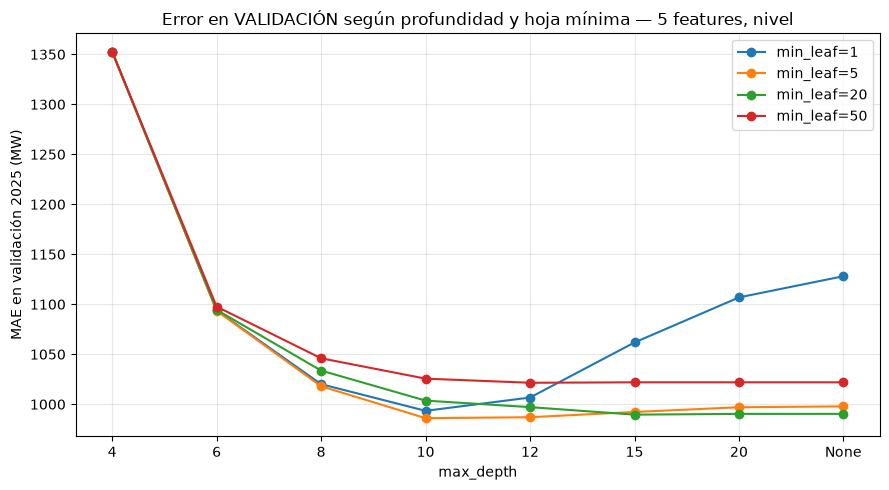


=== NIVEL · 5 features · {'max_depth': 10, 'min_samples_leaf': 5} ===
MAE validación 2025 : 986 MW
MAE TEST 2026 H1    : 1,266 MW  (4.344 filas) | sesgo +755 MW
MAE TEST censo REE  : 1,263 MW  (4.336 filas, sin el 11-J)


In [19]:
# =============================================================================
# REJILLA SOBRE VALIDACIÓN — 5 features, objetivo en NIVEL
# Selección: train_fit (2023-2024) -> val (2025). Test 2026 H1 NO entra al bucle.
# =============================================================================

# --- 1. Partición de selección (test se queda fuera) --------------------------
# El lag_24 ya se calculó en la sección 'Modelo con retardo' sobre la serie contigua completa, así que
# este corte es un filtro de filas: no hay que recomputarlo. El lag del 2025-01-01
# cruza el corte hacia 2024 y eso es legítimo: mira al pasado.
años_sel = train_model_clean["datetime_utc"].dt.year
train_fit = train_model_clean[años_sel <= 2024].copy()
val = train_model_clean[años_sel == 2025].copy()

assert len(train_fit) + len(val) == len(train_model_clean), "el corte pierde filas"
assert train_fit["datetime_utc"].max() < val["datetime_utc"].min(), "solapamiento fit/val"
assert val["datetime_utc"].max() < test_model["datetime_utc"].min(), "val invade test"
N_VAL_5F = len(val)
print(f"train_fit {len(train_fit)} | val {N_VAL_5F} | test {len(test_model)} (intacto)")


# --- 2. Helper de barrido (se reutiliza en las secciones 'Temperatura' y 'MODELO DELTA — objetivo `demanda_real - demanda_lag_24`') ----
from src.modeling import barrido_validacion, dispersion_top


# Registro de lecturas de test. Se reinicia al ejecutar esta celda, de modo que
# un "Run All" completo permite exactamente una medición por etiqueta.
_TEST_MEDIDO = set()


# --- 3. Barrido ---------------------------------------------------------------
obj_nivel = lambda d: d["demanda_real"]

ranking_nivel = barrido_validacion(features_5f, obj_nivel,
                                   train_fit, val, rejilla_depth, rejilla_leaf)

print("\n--- TOP 5 (menor MAE en VALIDACIÓN 2025) ---")
print(ranking_nivel[["max_depth", "min_samples_leaf", "mae_fit",
                     "mae_val", "gap", "sesgo_val"]].head(5).to_string(index=False))

disp = dispersion_top(ranking_nivel)
print(f"\nDispersión del top-5: {disp:.2f} MW"
      + ("   <-- empates: la rejilla no está eligiendo, está desempatando ruido"
         if disp < 5 else ""))

params_nivel = ranking_nivel.iloc[0]["params"]
MAE_VAL_5F = ranking_nivel.iloc[0]["mae_val"]
print(f"Ganador por validación: {params_nivel} | MAE val = {MAE_VAL_5F:,.0f} MW")


# --- 4. Gráfica, ahora sobre validación ---------------------------------------
plt.figure(figsize=(9, 5))
for leaf in rejilla_leaf:
    sub = ranking_nivel[ranking_nivel.min_samples_leaf == leaf].sort_values("orden")
    plt.plot(range(len(sub)), sub["mae_val"], marker="o", label=f"min_leaf={leaf}")

plt.xticks(range(len(rejilla_depth)), [str(d) for d in rejilla_depth])
plt.xlabel("max_depth")
plt.ylabel("MAE en validación 2025 (MW)")
plt.title("Error en VALIDACIÓN según profundidad y hoja mínima — 5 features, nivel")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# --- 5. ÚNICA lectura de test -------------------------------------------------
# El ganador se reentrena con train_model_clean entero (2023-2025) y se mide una vez.
if "nivel_5f" in _TEST_MEDIDO:
    raise RuntimeError(
        "Test ya medido para 'nivel_5f' en esta pasada. Si de verdad hace falta "
        "repetirlo, _TEST_MEDIDO.clear() de forma explícita."
    )
_TEST_MEDIDO.add("nivel_5f")

modelo_nivel_final = DecisionTreeRegressor(random_state=42, **params_nivel)
modelo_nivel_final.fit(train_model_clean[features_5f],
                       obj_nivel(train_model_clean))

pred_test_nivel = modelo_nivel_final.predict(test_model[features_5f])
y_test_nivel = obj_nivel(test_model)

MAE_NIVEL = mean_absolute_error(y_test_nivel, pred_test_nivel)
SESGO_NIVEL = (y_test_nivel - pred_test_nivel).mean()

# Mismo censo que el benchmark de REE (4.336 filas, sin las 8 horas del 11-J).
# No es una segunda lectura de test: son las mismas predicciones, filtradas.
sin_evento = ~test_model["es_evento"].to_numpy()
MAE_NIVEL_4336 = mean_absolute_error(y_test_nivel[sin_evento], pred_test_nivel[sin_evento])

print(f"\n=== NIVEL · 5 features · {params_nivel} ===")
print(f"MAE validación 2025 : {MAE_VAL_5F:,.0f} MW")
print(f"MAE TEST 2026 H1    : {MAE_NIVEL:,.0f} MW  (4.344 filas) | sesgo {SESGO_NIVEL:+,.0f} MW")
print(f"MAE TEST censo REE  : {MAE_NIVEL_4336:,.0f} MW  (4.336 filas, sin el 11-J)")


Temperatura

Se cruza con 8 columnas de temperatura por zona climática (`tmin`/`tmax` × 4 zonas). Se excluye el 2023-12-15 completo (24 h) porque tras interpolar los huecos de AEMET esa fecha queda sin dato en Guadalquivir (Sevilla, única estación de esa zona).

La temperatura no entra en el modelo publicado. El motivo es fuga (data leakage). Esta columna es temperatura **observada** (endpoint `valores/climatologicos` de AEMET), y en producción a D+1 solo habría **previsión** de temperatura disponible, no la observada. No está disponible en AEMET un registro de temperaturas previstas. 

In [20]:
#descargar temperaturas
PATH_PROCESSED = DIR_PROCESSED / "df_final_zonas_temperaturas_2023_2026.parquet"
df_t = pd.read_parquet(PATH_PROCESSED, engine="pyarrow")
df_t

,fecha,tmin_cantabrico,tmin_continental,tmin_guadalquivir,tmin_mediterraneo,tmax_cantabrico,tmax_continental,tmax_guadalquivir,tmax_mediterraneo
0,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
1,2023-01-02,5.0,7.894004,9.8,7.093681,14.7,12.922244,13.6,16.329670
2,2023-01-03,3.2,2.593037,7.3,8.944505,15.0,13.800967,16.3,18.085714
3,2023-01-04,3.4,-0.671954,8.5,8.086538,17.7,13.380851,18.0,17.175000
4,2023-01-05,5.3,-0.851644,7.8,5.985165,17.7,12.435783,17.6,16.568956
...,...,...,...,...,...,...,...,...,...
1289,2026-07-13,21.5,20.548162,18.2,23.828297,30.7,33.880464,33.1,31.810440
1290,2026-07-14,21.2,17.707930,18.2,24.477198,32.1,37.546809,32.4,32.443681
1291,2026-07-15,21.8,20.387234,18.4,24.526374,30.8,37.068472,36.7,35.211538
1292,2026-07-16,19.4,20.255513,21.6,24.994505,29.5,35.594971,36.1,33.337363


In [21]:
df_d = df_features.copy()
# Construcción de la clave con casteo explícito a datetime64[ns]
df_d['fecha'] = (
    df_d['datetime_utc']
    .dt.tz_convert("Europe/Madrid")
    .dt.normalize()
    .dt.tz_localize(None)
    .astype("datetime64[ns]")
)

# 1. Comprobar dtype exacto
print("Dtype:", df_d['fecha'].dtype)
assert df_d['fecha'].dtype == 'datetime64[ns]', "El tipo de dato debe ser datetime64[ns]"

# 2. Número de fechas únicas
print("Fechas únicas:", df_d['fecha'].nunique())

# 3. Distribución de registros por día
print("\nFrecuencia de horas por día:")
print(df_d['fecha'].value_counts().value_counts())

# 4. Rango de fechas
print("\nFecha mínima:", df_d['fecha'].min())
print("Fecha máxima:", df_d['fecha'].max())

Dtype: datetime64[ns]
Fechas únicas: 1278

Frecuencia de horas por día:
count
24    1269
23       5
25       3
2        1
Name: count, dtype: int64

Fecha mínima: 2023-01-01 00:00:00
Fecha máxima: 2026-07-01 00:00:00


In [22]:
df_d_t = df_d.merge(df_t, on="fecha", how="left", validate="m:1")
df_d_t

,datetime_utc,demanda_real,demanda_prevista,es_evento,hora,mes,tipo_dia,es_festivo,es_puente,tipo_efectivo,demanda_lag_24,fecha,tmin_cantabrico,tmin_continental,tmin_guadalquivir,tmin_mediterraneo,tmax_cantabrico,tmax_continental,tmax_guadalquivir,tmax_mediterraneo
0,2023-01-01 00:00:00+00:00,19292.000000,19383.750000,False,1,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
1,2023-01-01 01:00:00+00:00,18155.416667,18216.083333,False,2,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
2,2023-01-01 02:00:00+00:00,17120.083333,17126.666667,False,3,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
3,2023-01-01 03:00:00+00:00,16552.583333,16551.666667,False,4,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
4,2023-01-01 04:00:00+00:00,16191.000000,16185.750000,False,5,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30643,2026-06-30 19:00:00+00:00,37263.250000,37071.666667,False,21,6,laborable,False,False,0,36506.916667,2026-06-30,19.4,19.830754,22.7,23.901923,25.4,36.886460,40.3,32.528022
30644,2026-06-30 20:00:00+00:00,35701.750000,35196.083333,False,22,6,laborable,False,False,0,34625.250000,2026-06-30,19.4,19.830754,22.7,23.901923,25.4,36.886460,40.3,32.528022
30645,2026-06-30 21:00:00+00:00,32987.916667,32756.333333,False,23,6,laborable,False,False,0,31886.166667,2026-06-30,19.4,19.830754,22.7,23.901923,25.4,36.886460,40.3,32.528022
30646,2026-06-30 22:00:00+00:00,30548.416667,30797.333333,False,0,7,laborable,False,False,0,29683.916667,2026-07-01,17.7,20.800967,23.9,23.888187,24.4,36.115667,43.1,31.285714


In [23]:
#excluir día donde faltan datos de aemet
df_d_t = df_d_t[df_d_t['fecha'] != '2023-12-15'].reset_index(drop=True)
df_d_t

,datetime_utc,demanda_real,demanda_prevista,es_evento,hora,mes,tipo_dia,es_festivo,es_puente,tipo_efectivo,demanda_lag_24,fecha,tmin_cantabrico,tmin_continental,tmin_guadalquivir,tmin_mediterraneo,tmax_cantabrico,tmax_continental,tmax_guadalquivir,tmax_mediterraneo
0,2023-01-01 00:00:00+00:00,19292.000000,19383.750000,False,1,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
1,2023-01-01 01:00:00+00:00,18155.416667,18216.083333,False,2,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
2,2023-01-01 02:00:00+00:00,17120.083333,17126.666667,False,3,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
3,2023-01-01 03:00:00+00:00,16552.583333,16551.666667,False,4,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
4,2023-01-01 04:00:00+00:00,16191.000000,16185.750000,False,5,1,finde,True,False,1,NaN,2023-01-01,13.4,4.302901,6.7,7.154945,25.1,15.880851,16.4,17.274176
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30619,2026-06-30 19:00:00+00:00,37263.250000,37071.666667,False,21,6,laborable,False,False,0,36506.916667,2026-06-30,19.4,19.830754,22.7,23.901923,25.4,36.886460,40.3,32.528022
30620,2026-06-30 20:00:00+00:00,35701.750000,35196.083333,False,22,6,laborable,False,False,0,34625.250000,2026-06-30,19.4,19.830754,22.7,23.901923,25.4,36.886460,40.3,32.528022
30621,2026-06-30 21:00:00+00:00,32987.916667,32756.333333,False,23,6,laborable,False,False,0,31886.166667,2026-06-30,19.4,19.830754,22.7,23.901923,25.4,36.886460,40.3,32.528022
30622,2026-06-30 22:00:00+00:00,30548.416667,30797.333333,False,0,7,laborable,False,False,0,29683.916667,2026-07-01,17.7,20.800967,23.9,23.888187,24.4,36.115667,43.1,31.285714


In [24]:
assert df_d_t.isna().sum().sum() == 24
assert df_d_t['demanda_lag_24'].isna().sum() == 24

In [25]:
# 1. Extraer el año directamente de la clave UTC para hacer la partición
años_utc = df_d_t["datetime_utc"].dt.year

# 2. Crear las particiones temporales (sin barajar)
train = df_d_t[años_utc.isin([2023, 2024, 2025])].copy()
test = df_d_t[años_utc == 2026].copy()

# 3. VERIFICACIONES OBLIGATORIAS DE LOS CORTES

print("--- VALIDACIÓN DE FECHAS LÍMITE ---")
print(f"Train: desde {train['datetime_utc'].min()} hasta {train['datetime_utc'].max()}")
print(f"Test:  desde {test['datetime_utc'].min()} hasta {test['datetime_utc'].max()}")

print("\n--- VALIDACIÓN DE REGISTROS Y VOLUMEN ---")
filas_train = len(train)
filas_test = len(test)
total_particiones = filas_train + filas_test
total_original = len(df_d_t)

print(f"Filas en Train: {filas_train}")
print(f"Filas en Test:  {filas_test}")
print(f"Suma de particiones: {total_particiones} | Total esperado: {total_original}")

# Assertions de seguridad
assert total_particiones == total_original, f"¡Alerta! Las filas no cuadran. Suma: {total_particiones}"
assert train["datetime_utc"].max() < test["datetime_utc"].min(), "¡Alerta! Existe solapamiento temporal entre Train y Test."

print("\n✔ Partición temporal completada con éxito. Cero solapamientos.")

--- VALIDACIÓN DE FECHAS LÍMITE ---
Train: desde 2023-01-01 00:00:00+00:00 hasta 2025-12-31 23:00:00+00:00
Test:  desde 2026-01-01 00:00:00+00:00 hasta 2026-06-30 23:00:00+00:00

--- VALIDACIÓN DE REGISTROS Y VOLUMEN ---
Filas en Train: 26280
Filas en Test:  4344
Suma de particiones: 30624 | Total esperado: 30624

✔ Partición temporal completada con éxito. Cero solapamientos.


In [26]:
train_clean = train.dropna(subset=["demanda_lag_24"]).copy()
assert len(train_clean) == 26256, len(train_clean)
assert test["demanda_lag_24"].isna().sum() == 0

In [27]:
# =============================================================================
# PREPARACIÓN DE X E Y (ENFOQUE DE LISTA BLANCA EXPLÍCITA)
# =============================================================================

# 2. Separar X e y para el conjunto de entrenamiento (Train)
X_train = train_clean[features_13f].copy()
y_train = train_clean[variable_objetivo].copy()

# 3. Separar X e y para el conjunto de prueba (Test)
X_test = test[features_13f].copy()
y_test = test[variable_objetivo].copy()

In [28]:
assert X_train.shape == (26256, 13), X_train.shape
assert X_test.shape == (4344, 13), X_test.shape
assert X_train.isna().sum().sum() == 0 and X_test.isna().sum().sum() == 0

train_fit 17496 | val 8760 | test 4344 (intacto)

--- TOP 5 (menor MAE en VALIDACIÓN 2025) — 13 features ---
max_depth  min_samples_leaf    mae_fit    mae_val        gap  sesgo_val
       15                20 596.982936 967.941079 370.958143 186.890123
       12                20 618.688930 968.300463 349.611533 189.861330
       20                20 588.584436 969.632214 381.047777 185.669526
     None                20 588.364977 970.072634 381.707657 185.967730
       10                20 658.009630 980.391371 322.381740 188.539080

Dispersión del top-5: 12.45 MW

=== ¿Aporta la temperatura? (comparación en VALIDACIÓN 2025) ===
5 features  : 986 MW   {'max_depth': 10, 'min_samples_leaf': 5}
13 features : 968 MW   {'max_depth': 15, 'min_samples_leaf': 20}
Diferencia  : -18 MW

Dispersión del top-5 = 12.45 MW (>= umbral 5) -> el hiperparámetro sí mueve el resultado; la curva no es plana.


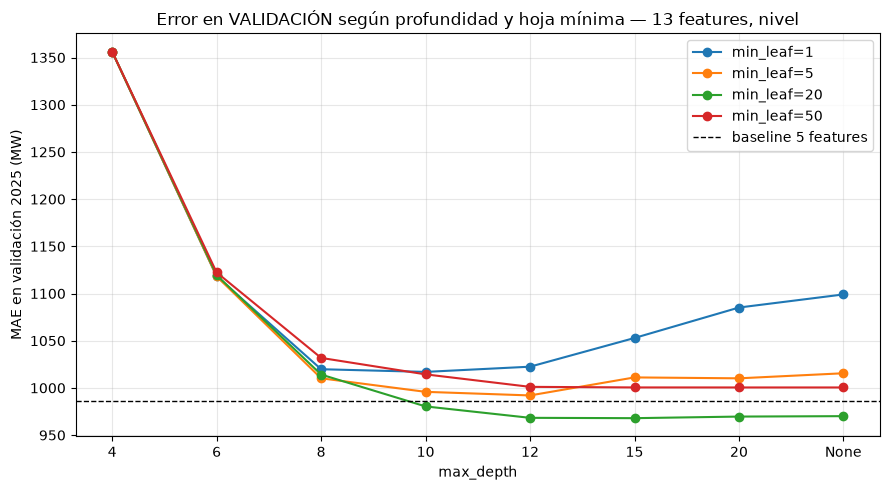

In [29]:
# =============================================================================
# REJILLA SOBRE VALIDACIÓN — 13 features (calendario + 8 temperaturas), NIVEL
# Aquí NO se lee test: esta celda existe para decidir si la temperatura aporta,
# y esa decisión se toma contra validación. El presupuesto de test se gasta en
# los dos modelos que se publican (sección 'Ajustando parámetros' = nivel, sección 'MODELO DELTA — objetivo `demanda_real - demanda_lag_24`' = delta).
# =============================================================================

# --- 1. Partición de selección, sobre train_clean (el de df_d_t) --------------
años_sel = train_clean["datetime_utc"].dt.year
train_fit = train_clean[años_sel <= 2024].copy()
val = train_clean[años_sel == 2025].copy()

assert len(train_fit) + len(val) == len(train_clean), "el corte pierde filas"
assert train_fit["datetime_utc"].max() < val["datetime_utc"].min(), "solapamiento fit/val"
assert val["datetime_utc"].max() < test["datetime_utc"].min(), "val invade test"

# La exclusión del 2023-12-15 solo quita filas de 2023, así que la validación de
# 2025 tiene que ser exactamente la misma que la de la sección 'Ajustando parámetros'. Si no, la
# comparación 5 vs 13 features no es sobre el mismo censo y no vale.
assert len(val) == N_VAL_5F, f"val distinta: {len(val)} vs {N_VAL_5F}"
print(f"train_fit {len(train_fit)} | val {len(val)} | test {len(test)} (intacto)")


# --- 2. Barrido ---------------------------------------------------------------
ranking_13f = barrido_validacion(features_13f, obj_nivel,
                                 train_fit, val, rejilla_depth, rejilla_leaf)

print("\n--- TOP 5 (menor MAE en VALIDACIÓN 2025) — 13 features ---")
print(ranking_13f[["max_depth", "min_samples_leaf", "mae_fit",
                   "mae_val", "gap", "sesgo_val"]].head(5).to_string(index=False))

disp = dispersion_top(ranking_13f)
print(f"\nDispersión del top-5: {disp:.2f} MW"
      + ("   <-- empates: la rejilla no está eligiendo, está desempatando ruido"
         if disp < 5 else ""))

params_13f = ranking_13f.iloc[0]["params"]
MAE_VAL_13F = ranking_13f.iloc[0]["mae_val"]


# --- 3. El resultado negativo, decidido sobre validación ----------------------
print(f"\n=== ¿Aporta la temperatura? (comparación en VALIDACIÓN 2025) ===")
print(f"5 features  : {MAE_VAL_5F:,.0f} MW   {params_nivel}")
print(f"13 features : {MAE_VAL_13F:,.0f} MW   {params_13f}")
print(f"Diferencia  : {MAE_VAL_13F - MAE_VAL_5F:+,.0f} MW")
if disp < 5:
    print("\nCurva plana en profundidad (dispersión top-5 < 5 MW) -> no hay hiperparámetro que lo salve.")
else:
    print(f"\nDispersión del top-5 = {disp:.2f} MW (>= umbral 5) -> el hiperparámetro sí mueve el resultado; la curva no es plana.")


# --- 4. Gráfica sobre validación ----------------------------------------------
plt.figure(figsize=(9, 5))
for leaf in rejilla_leaf:
    sub = ranking_13f[ranking_13f.min_samples_leaf == leaf].sort_values("orden")
    plt.plot(range(len(sub)), sub["mae_val"], marker="o", label=f"min_leaf={leaf}")

plt.axhline(MAE_VAL_5F, ls="--", c="k", lw=1, label="baseline 5 features")
plt.xticks(range(len(rejilla_depth)), [str(d) for d in rejilla_depth])
plt.xlabel("max_depth")
plt.ylabel("MAE en validación 2025 (MW)")
plt.title("Error en VALIDACIÓN según profundidad y hoja mínima — 13 features, nivel")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [30]:
print(y_train.mean(), y_test.mean(), y_test.mean() - y_train.mean())
print((y_test - test["demanda_lag_24"]).mean())

26618.1008150518 28855.152816144873 2237.052001093074
40.80991022099448


In [31]:
if "nivel_13f" in _TEST_MEDIDO:
    raise RuntimeError("Test ya medido para 'nivel_13f'.")
_TEST_MEDIDO.add("nivel_13f")

# 1. Árbol
modelo_13f = DecisionTreeRegressor(max_depth=15, min_samples_leaf=20, random_state=42)
modelo_13f.fit(X_train, y_train)

# 2. Predicciones
predicciones_train_t = modelo_13f.predict(X_train)
predicciones_test_t = modelo_13f.predict(X_test)

# 3. Métricas de Error Absoluto (MAE)
mae_train_t = mean_absolute_error(y_train, predicciones_train_t)
mae_test_t = mean_absolute_error(y_test, predicciones_test_t)

# 4. Cálculo del Sesgo Medio (Signo del error en Test)
# (y_test - pred_test) -> Positivo significa que la realidad supera a la predicción
sesgo_test_t = (y_test - predicciones_test_t).mean()

print("--- DIAGNÓSTICO CON MAX_DEPTH=15 ---")
print(f"--- ÁRBOL depth={modelo_13f.max_depth}, "
      f"leaf={modelo_13f.min_samples_leaf}, "
      f"{X_train.shape[1]} features ---")
print(f"MAE en Prueba (Test):         {mae_test_t:.2f} MW")
print(f"Sesgo Medio en Test:          {sesgo_test_t:.2f} MW")

importancias = (
    pd.Series(modelo_13f.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
print(importancias.round(4))

--- DIAGNÓSTICO CON MAX_DEPTH=15 ---
--- ÁRBOL depth=15, leaf=20, 13 features ---
MAE en Prueba (Test):         1374.13 MW
Sesgo Medio en Test:          946.12 MW
demanda_lag_24       0.6483
tipo_efectivo        0.1635
hora                 0.1243
tmax_guadalquivir    0.0141
tmax_continental     0.0139
tmin_mediterraneo    0.0132
tmax_mediterraneo    0.0059
mes                  0.0054
tmax_cantabrico      0.0035
tmin_guadalquivir    0.0035
tmin_cantabrico      0.0023
tmin_continental     0.0021
es_puente            0.0000
dtype: float64


MODELO DELTA — objetivo `demanda_real - demanda_lag_24`

1. Concepto y fundamento
Enfoque: Predice la variación respecto al día anterior (demanda_real - demanda_lag_24) y reconstruye el nivel sumando el lag a posteriori.

Por qué funciona: Al ser un modelo basado en árboles, sus predicciones quedan acotadas al rango de entrenamiento. Dado que 2026 está +2.237 MW por encima del nivel medio de train, el modelo directo se satura en ese techo. El delta elimina el nivel del problema, operando dentro del rango conocido.

2. Evidencia experimental
Eliminación del sesgo: Cambiar el objetivo a delta reduce el sesgo de test de +755 MW a +18 MW.

Prueba frente a profundidad de árbol: En el modelo de nivel, reducir la profundidad (depth=6) aumenta el sesgo a 788 MW, descartando que el sobreajuste o la profundidad explicaran dicho comportamiento.

3. Resultados en test (con hiperparámetros validados)
Sesgo: +18 MW (frente a +755 MW del modelo de nivel).

MAE: 1.617 MW (frente a 1.266 MW del modelo de nivel).

Balance: El modelo elimina la desviación de nivel (acierta el promedio), pero pierde cierta precisión en el perfil fino de la curva (empeora en forma).

In [32]:
# =============================================================================
# MODELO DELTA — objetivo `demanda_real - demanda_lag_24`, 12 features
# Los hiperparámetros se eligen en validación y test se lee UNA vez.
# (Antes: depth=8/leaf=1 fijos, heredados de la rejilla ordenada por mae_test.)
# =============================================================================

obj_delta = lambda d: d["demanda_real"] - d["demanda_lag_24"]

# --- 2. Partición de selección (misma que la sección 'Temperatura') ------------------------
años_sel = train_clean["datetime_utc"].dt.year
train_fit = train_clean[años_sel <= 2024].copy()
val = train_clean[años_sel == 2025].copy()
assert len(val) == N_VAL_5F, f"val distinta: {len(val)} vs {N_VAL_5F}"

# --- 3. Barrido sobre validación ----------------------------------------------
ranking_delta = barrido_validacion(features_delta, obj_delta,
                                   train_fit, val, rejilla_depth, rejilla_leaf)

print("--- TOP 5 (menor MAE en VALIDACIÓN 2025) — delta, 12 features ---")
print(ranking_delta[["max_depth", "min_samples_leaf", "mae_fit",
                     "mae_val", "gap", "sesgo_val"]].head(5).to_string(index=False))

disp = dispersion_top(ranking_delta)
print(f"\nDispersión del top-5: {disp:.2f} MW"
      + ("   <-- empates: la rejilla no está eligiendo, está desempatando ruido"
         if disp < 5 else ""))

params_delta = ranking_delta.iloc[0]["params"]
MAE_VAL_DELTA = ranking_delta.iloc[0]["mae_val"]
print(f"Ganador por validación: {params_delta} | MAE val = {MAE_VAL_DELTA:,.0f} MW")


# --- 4. ÚNICA lectura de test -------------------------------------------------
if "delta_12f" in _TEST_MEDIDO:
    raise RuntimeError(
        "Test ya medido para 'delta_12f' en esta pasada. Si de verdad hace falta "
        "repetirlo, _TEST_MEDIDO.clear() de forma explícita."
    )
_TEST_MEDIDO.add("delta_12f")

modelo_delta_final = DecisionTreeRegressor(random_state=42, **params_delta)
modelo_delta_final.fit(train_clean[features_delta], obj_delta(train_clean))

# Predicción en delta y reconstrucción a nivel (MW). El MAE es el mismo en ambas
# escalas: reconstruir es sumar lag_24, un desplazamiento que deja los residuos igual.
pred_test_delta = modelo_delta_final.predict(test[features_delta])
pred_test_mw = pred_test_delta + test["demanda_lag_24"]

MAE_DELTA = mean_absolute_error(test["demanda_real"], pred_test_mw)
SESGO_DELTA = (test["demanda_real"] - pred_test_mw).mean()

sin_evento = ~test["es_evento"].to_numpy()
MAE_DELTA_4336 = mean_absolute_error(test["demanda_real"][sin_evento],
                                     pred_test_mw[sin_evento])

print(f"\n=== DELTA · 12 features · {params_delta} ===")
print(f"MAE validación 2025 : {MAE_VAL_DELTA:,.0f} MW")
print(f"MAE TEST 2026 H1    : {MAE_DELTA:,.0f} MW  (4.344 filas) | sesgo {SESGO_DELTA:+,.0f} MW")
print(f"MAE TEST censo REE  : {MAE_DELTA_4336:,.0f} MW  (4.336 filas, sin el 11-J)")

print("\n--- IMPORTANCIA DE FEATURES ---")
importancias = (
    pd.Series(modelo_delta_final.feature_importances_, index=features_delta)
    .sort_values(ascending=False)
)
print(importancias.round(4))


# =============================================================================
# LOS DOS NÚMEROS DEL README
# =============================================================================
print("\n" + "=" * 62)
print(f"NIVEL (5 features) : {MAE_NIVEL:,.0f} MW  | sesgo {SESGO_NIVEL:+,.0f} MW")
print(f"DELTA (12 features): {MAE_DELTA:,.0f} MW  | sesgo {SESGO_DELTA:+,.0f} MW")
print(f"Censo REE (4.336)  : nivel {MAE_NIVEL_4336:,.0f} | delta {MAE_DELTA_4336:,.0f}")
print("Hiperparámetros elegidos en validación 2025. Test leído una vez por modelo.")
print("=" * 62)


--- TOP 5 (menor MAE en VALIDACIÓN 2025) — delta, 12 features ---
max_depth  min_samples_leaf     mae_fit     mae_val        gap  sesgo_val
        4                50 1458.637868 1583.134829 124.496961 -10.214206
        4                20 1458.473948 1583.652133 125.178186 -10.676859
        6                50 1392.946108 1594.378818 201.432710  -0.752608
        8                 1 1303.832023 1596.980462 293.148439 -13.920483
        4                 1 1454.691552 1600.163100 145.471548 -27.169920

Dispersión del top-5: 17.03 MW
Ganador por validación: {'max_depth': 4, 'min_samples_leaf': 50} | MAE val = 1,583 MW

=== DELTA · 12 features · {'max_depth': 4, 'min_samples_leaf': 50} ===
MAE validación 2025 : 1,583 MW
MAE TEST 2026 H1    : 1,617 MW  (4.344 filas) | sesgo +18 MW
MAE TEST censo REE  : 1,612 MW  (4.336 filas, sin el 11-J)

--- IMPORTANCIA DE FEATURES ---
tipo_efectivo        0.8308
hora                 0.1493
tmax_continental     0.0185
tmin_guadalquivir    0.0008
tmax

In [33]:
# =============================================================================
# BASELINE DE PERSISTENCIA: el mismo horizonte que el modelo
# =============================================================================
# La previsión oficial de REE (indicador 544) no es la vara de medir aquí: se
# refresca cada 5 minutos con reajuste intradiario, mientras que el modelo
# predice D+1 completo desde las 00:00. La persistencia pura (demanda_lag_24)
# es la comparación al mismo horizonte, y es lo que hay que batir.

MAE_PERSISTENCIA = mean_absolute_error(test["demanda_real"], test["demanda_lag_24"])

sin_evento = ~test["es_evento"].to_numpy()
MAE_PERSISTENCIA_4336 = mean_absolute_error(
    test["demanda_real"][sin_evento], test["demanda_lag_24"][sin_evento]
)

print(f"MAE PERSISTENCIA           : {MAE_PERSISTENCIA:,.0f} MW  (4.344 filas)")
print(f"MAE PERSISTENCIA censo REE : {MAE_PERSISTENCIA_4336:,.0f} MW  (4.336 filas, sin el 11-J)")


MAE PERSISTENCIA           : 1,843 MW  (4.344 filas)
MAE PERSISTENCIA censo REE : 1,840 MW  (4.336 filas, sin el 11-J)


In [34]:
res = test["demanda_real"] - pred_test_mw
print(res.abs().groupby(test["tipo_efectivo"]).mean())
print(res.abs().groupby(test["hora"]).mean().round(0))

tipo_efectivo
0    1782.059824
1    1247.434994
dtype: float64
hora
0      925.0
1      860.0
2      757.0
3      684.0
4      657.0
5      702.0
6     1480.0
7     2256.0
8     2579.0
9     2319.0
10    2016.0
11    1932.0
12    1901.0
13    1888.0
14    1877.0
15    1970.0
16    2037.0
17    2082.0
18    2034.0
19    2114.0
20    1933.0
21    1693.0
22    1207.0
23     903.0
dtype: float64


Demanda lag_168

Se explora `demanda_lag_168` (la demanda de la misma hora, 7 días antes -- captura estacionalidad semanal desde la propia serie, sin fuente nueva). Dos rejillas la prueban: combinada con temperatura (14 features, celda de abajo) y sola junto al resto de calendario (5 features + lag_168, sin `es_puente`). Ambas comparaciones de esta sección son de un solo corte de validación (2025); el veredicto que se sostiene fuera de ese corte concreto viene de la validación móvil de la sección siguiente, no de aquí.

In [35]:
# Fusión de celdas del pliego (§1.2): merge con temperaturas -> lag_168 -> excluir 2023-12-15.
df_d_t = df_d.merge(df_t, on="fecha", how="left", validate="m:1")
df_d_t["demanda_lag_168"] = df_d_t["demanda_real"].shift(168)
df_d_t = df_d_t[df_d_t['fecha'] != '2023-12-15'].reset_index(drop=True)
assert len(df_d_t) == 30624


In [36]:
años_utc = df_d_t["datetime_utc"].dt.year

train = df_d_t[años_utc.isin([2023, 2024, 2025])].copy()
test = df_d_t[años_utc == 2026].copy()

# 3. VERIFICACIONES OBLIGATORIAS DE LOS CORTES

print("--- VALIDACIÓN DE FECHAS LÍMITE ---")
print(f"Train: desde {train['datetime_utc'].min()} hasta {train['datetime_utc'].max()}")
print(f"Test:  desde {test['datetime_utc'].min()} hasta {test['datetime_utc'].max()}")

print("\n--- VALIDACIÓN DE REGISTROS Y VOLUMEN ---")
filas_train = len(train)
filas_test = len(test)
total_particiones = filas_train + filas_test
total_original = len(df_d_t)

print(f"Filas en Train: {filas_train}")
print(f"Filas en Test:  {filas_test}")
print(f"Suma de particiones: {total_particiones} | Total esperado: {total_original}")

# Assertions de seguridad
assert total_particiones == total_original, f"¡Alerta! Las filas no cuadran. Suma: {total_particiones}"
assert train["datetime_utc"].max() < test["datetime_utc"].min(), "¡Alerta! Existe solapamiento temporal entre Train y Test."

print("\n✔ Partición temporal completada con éxito. Cero solapamientos.")


--- VALIDACIÓN DE FECHAS LÍMITE ---
Train: desde 2023-01-01 00:00:00+00:00 hasta 2025-12-31 23:00:00+00:00
Test:  desde 2026-01-01 00:00:00+00:00 hasta 2026-06-30 23:00:00+00:00

--- VALIDACIÓN DE REGISTROS Y VOLUMEN ---
Filas en Train: 26280
Filas en Test:  4344
Suma de particiones: 30624 | Total esperado: 30624

✔ Partición temporal completada con éxito. Cero solapamientos.


In [37]:
train_clean = train.dropna(subset=["demanda_lag_24", "demanda_lag_168"]).copy()
assert len(train_clean) == 26112, len(train_clean)
assert test["demanda_lag_24"].isna().sum() == 0
assert test["demanda_lag_168"].isna().sum() == 0

In [38]:
# =============================================================================
# PREPARACIÓN DE X E Y (ENFOQUE DE LISTA BLANCA EXPLÍCITA)
# =============================================================================

# 2. Separar X e y para el conjunto de entrenamiento (Train)

X_train = train_clean[features_14f].copy()
y_train = train_clean[variable_objetivo].copy()

# 3. Separar X e y para el conjunto de prueba (Test)
X_test = test[features_14f].copy()
y_test = test[variable_objetivo].copy()


# 1. Árbol
modelo_14f = DecisionTreeRegressor(max_depth=8, min_samples_leaf=1, random_state=42)
modelo_14f.fit(X_train, y_train)

# 2. Predicciones
predicciones_train_t = modelo_14f.predict(X_train)
predicciones_test_t = modelo_14f.predict(X_test)

# 3. Métricas de Error Absoluto (MAE)
mae_train_t = mean_absolute_error(y_train, predicciones_train_t)
mae_test_t = mean_absolute_error(y_test, predicciones_test_t)

# 4. Cálculo del Sesgo Medio (Signo del error en Test)
# (y_test - pred_test) -> Positivo significa que la realidad supera a la predicción
sesgo_test_t = (y_test - predicciones_test_t).mean()

print("--- DIAGNÓSTICO CON MAX_DEPTH=8 ---")
print(f"--- ÁRBOL depth={modelo_14f.max_depth}, "
      f"leaf={modelo_14f.min_samples_leaf}, "
      f"{X_train.shape[1]} features ---")
print(f"MAE en Prueba (Test):         {mae_test_t:.2f} MW")
print(f"Sesgo Medio en Test:          {sesgo_test_t:.2f} MW")

importancias = (
    pd.Series(modelo_14f.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)
print(importancias.round(4))

--- DIAGNÓSTICO CON MAX_DEPTH=8 ---
--- ÁRBOL depth=8, leaf=1, 14 features ---
MAE en Prueba (Test):         1158.04 MW
Sesgo Medio en Test:          654.19 MW
demanda_lag_168      0.7425
demanda_lag_24       0.1680
tipo_efectivo        0.0500
hora                 0.0176
tmax_continental     0.0098
tmax_mediterraneo    0.0024
tmax_guadalquivir    0.0024
tmin_continental     0.0021
mes                  0.0020
tmin_mediterraneo    0.0018
tmin_guadalquivir    0.0008
tmin_cantabrico      0.0007
tmax_cantabrico      0.0000
es_puente            0.0000
dtype: float64


train_fit 17352 | val 8760 | test 4344 (intacto)

--- TOP 5 (menor MAE en VALIDACIÓN 2025) — 14 features ---
max_depth  min_samples_leaf    mae_fit    mae_val        gap  sesgo_val
       15                20 576.434616 971.039239 394.604623 156.783497
       12                 5 467.882097 971.368454 503.486357 169.963288
       20                20 572.858804 973.965712 401.106908 159.761211
     None                20 572.858804 973.965712 401.106908 159.761211
       12                20 599.263602 975.615619 376.352018 161.188147

Dispersión del top-5: 4.58 MW   <-- empates: la rejilla no está eligiendo, está desempatando ruido

=== ¿Aportan temperatura + lag_168 sobre el baseline de 5 features? (comparación en VALIDACIÓN 2025) ===
5 features  : 986 MW   {'max_depth': 10, 'min_samples_leaf': 5}
14 features : 971 MW   {'max_depth': 15, 'min_samples_leaf': 20}
Diferencia  : -15 MW

Curva plana en profundidad (dispersión top-5 < 5 MW) -> no hay hiperparámetro que lo salve.


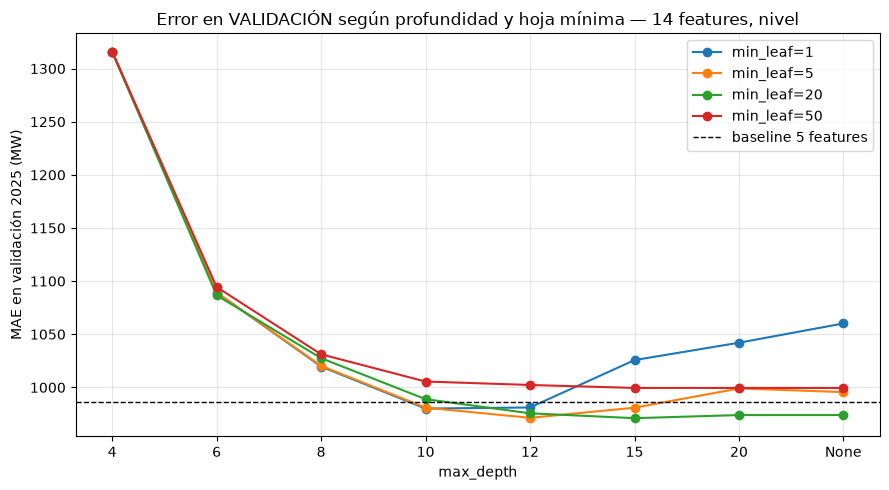

In [39]:
# =============================================================================
# REJILLA SOBRE VALIDACIÓN — 14 features (calendario + 8 temperaturas + 2 lags), NIVEL
# Aquí NO se lee test: la decisión se toma contra validación.
# =============================================================================

# --- 1. Partición de selección, sobre train_clean (el de df_d_t) --------------
años_sel = train_clean["datetime_utc"].dt.year
train_fit = train_clean[años_sel <= 2024].copy()
val = train_clean[años_sel == 2025].copy()

assert len(train_fit) + len(val) == len(train_clean), "el corte pierde filas"
assert train_fit["datetime_utc"].max() < val["datetime_utc"].min(), "solapamiento fit/val"
assert val["datetime_utc"].max() < test["datetime_utc"].min(), "val invade test"

# La exclusión del 2023-12-15 solo quita filas de 2023, así que la validación de
# 2025 tiene que ser exactamente la misma que la de la sección 'Ajustando parámetros'. Si no, la
# comparación 5 vs 14 features no es sobre el mismo censo y no vale.
assert len(val) == N_VAL_5F, f"val distinta: {len(val)} vs {N_VAL_5F}"
print(f"train_fit {len(train_fit)} | val {len(val)} | test {len(test)} (intacto)")


# --- 2. Barrido ---------------------------------------------------------------
ranking_14f = barrido_validacion(features_14f, obj_nivel,
                                 train_fit, val, rejilla_depth, rejilla_leaf)

print("\n--- TOP 5 (menor MAE en VALIDACIÓN 2025) — 14 features ---")
print(ranking_14f[["max_depth", "min_samples_leaf", "mae_fit",
                   "mae_val", "gap", "sesgo_val"]].head(5).to_string(index=False))

disp = dispersion_top(ranking_14f)
print(f"\nDispersión del top-5: {disp:.2f} MW"
      + ("   <-- empates: la rejilla no está eligiendo, está desempatando ruido"
         if disp < 5 else ""))

params_14f = ranking_14f.iloc[0]["params"]
MAE_VAL_14F = ranking_14f.iloc[0]["mae_val"]


# --- 3. El resultado negativo, decidido sobre validación ----------------------
print(f"\n=== ¿Aportan temperatura + lag_168 sobre el baseline de 5 features? (comparación en VALIDACIÓN 2025) ===")
print(f"5 features  : {MAE_VAL_5F:,.0f} MW   {params_nivel}")
print(f"14 features : {MAE_VAL_14F:,.0f} MW   {params_14f}")
print(f"Diferencia  : {MAE_VAL_14F - MAE_VAL_5F:+,.0f} MW")
if disp < 5:
    print("\nCurva plana en profundidad (dispersión top-5 < 5 MW) -> no hay hiperparámetro que lo salve.")
else:
    print(f"\nDispersión del top-5 = {disp:.2f} MW (>= umbral 5) -> el hiperparámetro sí mueve el resultado; la curva no es plana.")


# --- 4. Gráfica sobre validación ----------------------------------------------
plt.figure(figsize=(9, 5))
for leaf in rejilla_leaf:
    sub = ranking_14f[ranking_14f.min_samples_leaf == leaf].sort_values("orden")
    plt.plot(range(len(sub)), sub["mae_val"], marker="o", label=f"min_leaf={leaf}")

plt.axhline(MAE_VAL_5F, ls="--", c="k", lw=1, label="baseline 5 features")
plt.xticks(range(len(rejilla_depth)), [str(d) for d in rejilla_depth])
plt.xlabel("max_depth")
plt.ylabel("MAE en validación 2025 (MW)")
plt.title("Error en VALIDACIÓN según profundidad y hoja mínima — 14 features, nivel")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

train_fit 17352 | val 8760 | test 4344 (intacto)

--- TOP 5 (menor MAE en VALIDACIÓN 2025) — 5 features con lag_168 ---
max_depth  min_samples_leaf    mae_fit     mae_val        gap  sesgo_val
       10                 1 629.438289  996.101826 366.663537 127.923385
       10                20 707.766653  999.753230 291.986577 126.362621
       10                 5 652.886691 1000.261450 347.374759 128.810904
       12                20 679.216816 1004.078859 324.862042 129.087260
       20                20 672.393516 1008.813183 336.419667 129.915525

Dispersión del top-5: 12.71 MW

=== ¿Aporta lag_168 sin temperatura? (comparación en VALIDACIÓN 2025) ===
5 features (lag_24, es_puente)      : 986 MW   {'max_depth': 10, 'min_samples_leaf': 5}
5 features (lag_24 + lag_168, sin es_puente): 996 MW   {'max_depth': 10, 'min_samples_leaf': 1}
Diferencia  : +10 MW

Dispersión del top-5 = 12.71 MW (>= umbral 5) -> el hiperparámetro sí mueve el resultado; la curva no es plana.


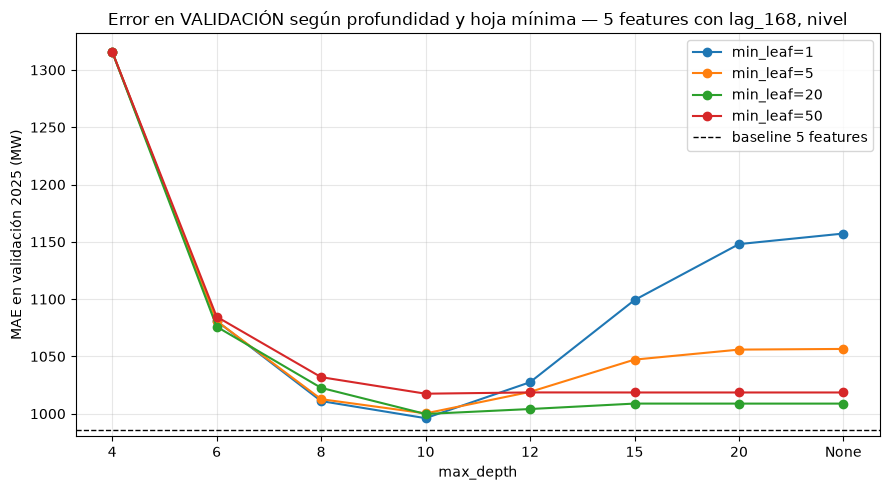

In [40]:
# =============================================================================
# REJILLA SOBRE VALIDACIÓN — 5 features con lag_168 (sin temperatura, sin es_puente), NIVEL
# Aquí NO se lee test: la decisión se toma contra validación.
# =============================================================================

# --- 1. Partición de selección, sobre train_clean (el de df_d_t) --------------
años_sel = train_clean["datetime_utc"].dt.year
train_fit = train_clean[años_sel <= 2024].copy()
val = train_clean[años_sel == 2025].copy()

assert len(train_fit) + len(val) == len(train_clean), "el corte pierde filas"
assert train_fit["datetime_utc"].max() < val["datetime_utc"].min(), "solapamiento fit/val"
assert val["datetime_utc"].max() < test["datetime_utc"].min(), "val invade test"

# La exclusión del 2023-12-15 solo quita filas de 2023, así que la validación de
# 2025 tiene que ser exactamente la misma que la de la sección 'Ajustando parámetros'. Si no, la
# comparación no es sobre el mismo censo y no vale.
assert len(val) == N_VAL_5F, f"val distinta: {len(val)} vs {N_VAL_5F}"
print(f"train_fit {len(train_fit)} | val {len(val)} | test {len(test)} (intacto)")


# --- 2. Barrido ---------------------------------------------------------------
ranking_5f_lag = barrido_validacion(features_lag168, obj_nivel,
                                 train_fit, val, rejilla_depth, rejilla_leaf)

print("\n--- TOP 5 (menor MAE en VALIDACIÓN 2025) — 5 features con lag_168 ---")
print(ranking_5f_lag[["max_depth", "min_samples_leaf", "mae_fit",
                   "mae_val", "gap", "sesgo_val"]].head(5).to_string(index=False))

disp = dispersion_top(ranking_5f_lag)
print(f"\nDispersión del top-5: {disp:.2f} MW"
      + ("   <-- empates: la rejilla no está eligiendo, está desempatando ruido"
         if disp < 5 else ""))

params_5f_lags = ranking_5f_lag.iloc[0]["params"]
MAE_VAL_5f_lags = ranking_5f_lag.iloc[0]["mae_val"]


# --- 3. El resultado negativo, decidido sobre validación ----------------------
print(f"\n=== ¿Aporta lag_168 sin temperatura? (comparación en VALIDACIÓN 2025) ===")
print(f"5 features (lag_24, es_puente)      : {MAE_VAL_5F:,.0f} MW   {params_nivel}")
print(f"5 features (lag_24 + lag_168, sin es_puente): {MAE_VAL_5f_lags:,.0f} MW   {params_5f_lags}")
print(f"Diferencia  : {MAE_VAL_5f_lags - MAE_VAL_5F:+,.0f} MW")
if disp < 5:
    print("\nCurva plana en profundidad (dispersión top-5 < 5 MW) -> no hay hiperparámetro que lo salve.")
else:
    print(f"\nDispersión del top-5 = {disp:.2f} MW (>= umbral 5) -> el hiperparámetro sí mueve el resultado; la curva no es plana.")


# --- 4. Gráfica sobre validación ----------------------------------------------
plt.figure(figsize=(9, 5))
for leaf in rejilla_leaf:
    sub = ranking_5f_lag[ranking_5f_lag.min_samples_leaf == leaf].sort_values("orden")
    plt.plot(range(len(sub)), sub["mae_val"], marker="o", label=f"min_leaf={leaf}")

plt.axhline(MAE_VAL_5F, ls="--", c="k", lw=1, label="baseline 5 features")
plt.xticks(range(len(rejilla_depth)), [str(d) for d in rejilla_depth])
plt.xlabel("max_depth")
plt.ylabel("MAE en validación 2025 (MW)")
plt.title("Error en VALIDACIÓN según profundidad y hoja mínima — 5 features con lag_168, nivel")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# 2. Separar X e y para el conjunto de entrenamiento (Train)

X_train = train_clean[features_lag168].copy()
y_train = train_clean[variable_objetivo].copy()

# 3. Separar X e y para el conjunto de prueba (Test)
X_test = test[features_lag168].copy()
y_test = test[variable_objetivo].copy()


# 1. Árbol
modelo_5f_lags = DecisionTreeRegressor(max_depth=10, min_samples_leaf=1, random_state=42)
modelo_5f_lags.fit(X_train, y_train)

# 2. Predicciones
predicciones_train_t = modelo_5f_lags.predict(X_train)
predicciones_test_t = modelo_5f_lags.predict(X_test)

# 3. Métricas de Error Absoluto (MAE)
mae_train_t = mean_absolute_error(y_train, predicciones_train_t)
mae_test_t = mean_absolute_error(y_test, predicciones_test_t)

# 4. Cálculo del Sesgo Medio (Signo del error en Test)
# (y_test - pred_test) -> Positivo significa que la realidad supera a la predicción
sesgo_test_t = (y_test - predicciones_test_t).mean()

print("--- DIAGNÓSTICO CON MAX_DEPTH=10 ---")
print(f"--- ÁRBOL depth={modelo_5f_lags.max_depth}, "
      f"leaf={modelo_5f_lags.min_samples_leaf}, "
      f"{X_train.shape[1]} features ---")
print(f"MAE en Prueba (Test):         {mae_test_t:.2f} MW")
print(f"Sesgo Medio en Test:          {sesgo_test_t:.2f} MW")

importancias = (
    pd.Series(modelo_5f_lags.feature_importances_, index=X_train.columns)
    .sort_values(ascending=False)
)

print(importancias.round(4))

--- DIAGNÓSTICO CON MAX_DEPTH=10 ---
--- ÁRBOL depth=10, leaf=1, 5 features ---
MAE en Prueba (Test):         1009.19 MW
Sesgo Medio en Test:          406.56 MW
demanda_lag_168    0.7388
demanda_lag_24     0.1762
tipo_efectivo      0.0493
hora               0.0254
mes                0.0103
dtype: float64


## Validación móvil (lag_168 vs. 5f)

1. Ruido en el corte único
Problema: Evaluar un solo corte (2023-24 → 2025) introduce ruido propio en la métrica.

Resultado móvil (V1 a V4): La diferencia fluctúa entre −29 y +14 MW según el semestre analizado.

Conclusión: Existe un rango de ruido de ±20 MW. Un único corte no permite discriminar entre una mejora real y variabilidad estadística.

2. Comportamiento por ventanas
V1 (nivel a la baja): Única ventana con victoria clara de lag_168.

V2, V3 y V4 (nivel al alza): Empate técnico según dispersion_top.

3. Hipótesis del salto de nivel (Falsada)
Premisa: Se preveía que lag_168 respondería mejor conforme aumentara el salto de nivel entre fit y validación.

Refutación: El rendimiento en V4 (salto de +1.101 MW) no supera al de V3 (+590 MW); los resultados se mantienen planos.

In [42]:
# 1. DEFINICIÓN DE VENTANAS

ventanas_def = [
    ("V1", "2023-12-31 23:59:59", "2024-01-01 00:00:00", "2024-06-30 23:59:59"),
    ("V2", "2024-06-30 23:59:59", "2024-07-01 00:00:00", "2024-12-31 23:59:59"),
    ("V3", "2024-12-31 23:59:59", "2025-01-01 00:00:00", "2025-06-30 23:59:59"),
    ("V4", "2025-06-30 23:59:59", "2025-07-01 00:00:00", "2025-12-31 23:59:59"),
]

min_test_date = test["datetime_utc"].min()
resultados_ventanas = []
prev_val_max = None

# 2. BUCLE DE EVALUACIÓN SOBRE CADA VENTANA
for nombre_v, fin_train, inicio_val, fin_val in ventanas_def:
    fit_w = train_clean[train_clean["datetime_utc"] <= fin_train].copy()
    val_w = train_clean[
        (train_clean["datetime_utc"] >= inicio_val)
        & (train_clean["datetime_utc"] <= fin_val)
    ].copy()

    # Asserts de seguridad
    assert len(fit_w) > 0 and len(val_w) > 0, f"¡Alerta! Ventana {nombre_v} vacía."
    assert fit_w["datetime_utc"].max() < val_w["datetime_utc"].min(), f"¡Alerta! Solapamiento temporal en {nombre_v}."
    assert val_w["datetime_utc"].max() < min_test_date, f"¡Alerta! {nombre_v} invade Test."

    if prev_val_max is not None:
        assert val_w["datetime_utc"].min() > prev_val_max, f"¡Alerta! Solapamiento entre bloques ({nombre_v})."
    prev_val_max = val_w["datetime_utc"].max()

    # Salto de nivel
    salto_nivel = val_w[variable_objetivo].mean() - fit_w[variable_objetivo].mean()

    # Barridos de validación
    res_base = barrido_validacion(features_base, lambda d: d[variable_objetivo], fit_w, val_w, rejilla_depth, rejilla_leaf)
    res_5f = barrido_validacion(features_5f, lambda d: d[variable_objetivo], fit_w, val_w, rejilla_depth, rejilla_leaf)
    res_lags = barrido_validacion(features_lag168, lambda d: d[variable_objetivo], fit_w, val_w, rejilla_depth, rejilla_leaf)

    # Métricas ganadoras (.iloc[0]) y dispersiones
    mae_base = res_base.iloc[0]["mae_val"]
    mae_5f = res_5f.iloc[0]["mae_val"]
    mae_lags = res_lags.iloc[0]["mae_val"]

    disp_base = dispersion_top(res_base)
    disp_5f = dispersion_top(res_5f)
    disp_lags = dispersion_top(res_lags)

    resultados_ventanas.append({
        "ventana": nombre_v,
        "n_fit": len(fit_w),
        "n_val": len(val_w),
        "salto_nivel": round(salto_nivel, 2),
        "mae_base": round(mae_base, 2),
        "mae_5f": round(mae_5f, 2),
        "mae_lags": round(mae_lags, 2),
        "dif_lags_5f": round(mae_lags - mae_5f, 2),
        "disp_base": round(disp_base, 4),
        "disp_5f": round(disp_5f, 4),
        "disp_lags": round(disp_lags, 4),
    })

# 3. CONSTRUCCIÓN Y PONDERACIÓN DEL CENSO TOTAL (4.336 FILAS)
df_ventanas = pd.DataFrame(resultados_ventanas)

total_n_val = df_ventanas["n_val"].sum()

# Cálculo del MAE global ponderado por el censo de cada ventana
mae_censo_base = (df_ventanas["mae_base"] * df_ventanas["n_val"]).sum() / total_n_val
mae_censo_5f = (df_ventanas["mae_5f"] * df_ventanas["n_val"]).sum() / total_n_val
mae_censo_lags = (df_ventanas["mae_lags"] * df_ventanas["n_val"]).sum() / total_n_val

# Añadir fila resumen al DataFrame
fila_censo = {
    "ventana": "TOTAL_CENSO",
    "n_fit": "-",
    "n_val": total_n_val,
    "salto_nivel": "-",
    "mae_base": round(mae_censo_base, 2),
    "mae_5f": round(mae_censo_5f, 2),
    "mae_lags": round(mae_censo_lags, 2),
    "dif_lags_5f": round(mae_censo_lags - mae_censo_5f, 2),
    "disp_base": "-",
    "disp_5f": "-",
    "disp_lags": "-",
}

df_ventanas = pd.concat([df_ventanas, pd.DataFrame([fila_censo])], ignore_index=True)

print("✔ Validación origen móvil completada sin errores.")
print(f"\nMAE Global lag_168 sobre el censo ({total_n_val} registros): {mae_censo_lags:.2f} MW")
print("\n--- RESUMEN DE EXPERIMENTACIÓN POR VENTANAS Y CENSO TOTAL ---")
print(df_ventanas.to_string(index=False))

✔ Validación origen móvil completada sin errores.

MAE Global lag_168 sobre el censo (17544 registros): 933.99 MW

--- RESUMEN DE EXPERIMENTACIÓN POR VENTANAS Y CENSO TOTAL ---
    ventana n_fit  n_val salto_nivel  mae_base  mae_5f  mae_lags  dif_lags_5f disp_base  disp_5f disp_lags
         V1  8568   4368     -195.76    904.80  906.33    876.99       -29.34    21.968  20.3975   15.3939
         V2 12936   4416      738.72    868.70  868.70    882.78        14.08    7.7488   7.7488   11.1529
         V3 17352   4344      589.91   1012.86 1012.60   1025.24        12.64   15.1289  15.3906   24.7959
         V4 21696   4416      1101.1    942.02  942.02    951.83         9.82   13.5489  14.1355    6.4109
TOTAL_CENSO     -  17544           -    931.84  932.15    933.99         1.84         -        -         -


## Resultados

1. Decisión y métricas
Resultado en test: lag_168 reduce error y sesgo respecto al publicado (1.005 MW vs. 1.263 MW; sesgo +413 MW vs. +755 MW).

Decisión: Se mantiene el modelo publicado.

Motivo: Sin diferencias significativas en validación; cambiarlo tras ver test incurriría en data leakage.

2. Análisis de validación y prueba de hipótesis
Corte único (2023-24 → 2025): Empate técnico (986,07 MW vs. 996,10 MW), dentro del ruido del procedimiento (±20 MW).

Aislamiento de variable: La diferencia real entre base y lag168 es una sola feature (demanda_lag_168). Nota: la métrica dif_lags_5f mezcla además la retirada de es_puente.

Hipótesis del salto de nivel (Falsada en origen móvil):

Solo gana donde el nivel baja (V1: −27,8 MW).

Pierde de forma plana donde el nivel sube (+14,1 / +12,4 / +9,8 MW), sin respuesta al tamaño del salto (V3 = +590 MW vs. V4 = +1.101 MW).

3. Factores de distorsión
Desplazamiento train/test: +2.237 MW (dobla la mayor ventana de validación).

Discrepancia en datos 2026: El agregado mensual crece un 3–12% interanual, frente al −1,1% / +0,5% reportado oficialmente por REE. Causa no determinada.

Otras diferencias: Variación de censo (26.280 vs. 26.112) e hiperparámetros procedentes de rejillas distintas.

4. Conclusión
La selección del modelo fue metodológicamente correcta. El desfase en test pone de manifiesto que optimizar solo el MAE global en validación no permite detectar divergencias de sesgo. Cause del desfase pendiente de diagnosticar.

In [43]:
assert X_test.shape[1] == 5, X_test.shape

# Mismo censo que el benchmark de REE (4.336 filas, sin las 8 horas del 11-J).
# No es una segunda lectura de test: son las predicciones de arriba, filtradas.
sin_evento = ~test["es_evento"].to_numpy()
assert sin_evento.sum() == 4336, sin_evento.sum()

MAE_LAG168      = mean_absolute_error(y_test, predicciones_test_t)
MAE_LAG168_4336 = mean_absolute_error(y_test[sin_evento], predicciones_test_t[sin_evento])
SESGO_LAG168_4336 = (y_test[sin_evento] - predicciones_test_t[sin_evento]).mean()

print(f"=== LAG_168 · 5 features · depth=10, leaf=1 ===")
print(f"MAE validación 2025 : {MAE_VAL_5f_lags:,.0f} MW")
print(f"MAE TEST 2026 H1    : {MAE_LAG168:,.0f} MW  (4.344 filas)")
print(f"MAE TEST censo REE  : {MAE_LAG168_4336:,.0f} MW  (4.336 filas, sin el 11-J)"
      f" | sesgo {SESGO_LAG168_4336:+,.0f} MW")

=== LAG_168 · 5 features · depth=10, leaf=1 ===
MAE validación 2025 : 996 MW
MAE TEST 2026 H1    : 1,009 MW  (4.344 filas)
MAE TEST censo REE  : 1,005 MW  (4.336 filas, sin el 11-J) | sesgo +413 MW
